In [1]:
####################################
# consolidated imports
####################################
# This notebook mirrors the harakat top-five-to-Arabizi trainer outline.
# The comments and section markers match the harakat_adder trainer style.
from __future__ import annotations

import math
import random
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(value):
        print(value)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
####################################
# GLOBAL CONFIGURATION & HYPERPARAMETERS
# All user-manipulated variables are defined here for easy tuning.
####################################
# This trainer mirrors the Arabic-with-harakat to Arabizi notebook, but trains
# directly on unvocalized/stripped Arabic. This gives a clean baseline for the
# report comparison against the harakat-aware model.
# Direction during training: arabic_stripped -> arabizi
# Final 1k softmax/top-k validation also uses arabic_stripped -> arabizi.

# ==========================================
# 1. FILE & DIRECTORY PATHS
# ==========================================
NOTEBOOK_STEM = "train_arabic_wo_harakat_to_arabizi"
CLEANED_FILE_NAME = "maknuune-v1.0.1_cleaned_predictions_top_5.csv"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    ARABIZI_DIR = Path("/content/drive/MyDrive/arabizi")
    DATA_DIR = ARABIZI_DIR
    RUNS_DIR = ARABIZI_DIR / f"{NOTEBOOK_STEM}_files"
except ModuleNotFoundError:
    ARABIZI_DIR = Path.cwd()
    data_dir_candidates = [
        ARABIZI_DIR / "working_files" / "data",
        ARABIZI_DIR / "data",
        ARABIZI_DIR.parent / "working_files" / "data",
        ARABIZI_DIR.parent / "data",
    ]
    DATA_DIR = next((path for path in data_dir_candidates if (path / CLEANED_FILE_NAME).exists()), data_dir_candidates[0])
    if (ARABIZI_DIR / "working_files").exists():
        RUNS_DIR = ARABIZI_DIR / "working_files" / NOTEBOOK_STEM / f"{NOTEBOOK_STEM}_files"
    else:
        RUNS_DIR = ARABIZI_DIR / f"{NOTEBOOK_STEM}_files"

PROJECT_DIR = ARABIZI_DIR
WORKING_DIR = RUNS_DIR
DATA_FILE = DATA_DIR / CLEANED_FILE_NAME
RESULTS_DIR = RUNS_DIR
METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_metrics.csv"
PROGRESS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_progress.csv"
LENGTH_METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_metrics_by_length.csv"
ERROR_ANALYSIS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_error_analysis_by_length.csv"
TOPK_PREDICTIONS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_arabizi_predictions_softmax_90.csv"
TOPK_METRICS_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_top_k_metrics.csv"
TOPK_BY_LENGTH_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_top_k_metrics_by_length.csv"
CHECKPOINT_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_checkpoint.pt"
MODEL_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}.pt"
BEST_MODEL_FILE = RESULTS_DIR / f"{NOTEBOOK_STEM}_best.pt"
MODEL_DIR = MODEL_FILE.parent

# In Colab, DATA_FILE and every saved artifact live under /content/drive/MyDrive/arabizi/.
# The local fallback only exists so the notebook can be syntax-checked outside Colab.
ARABIZI_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================
# 2. DATA COLUMNS
# ==========================================
SOURCE_COL = "arabic_stripped"
TOPK_SOURCE_COL = "arabic_stripped"
TARGET_COL = "arabizi"
TARGET_LANGUAGE_NAME = "arabizi"

# ==========================================
# 3. DATASET SPLITS & SEED
# ==========================================
SEED = 42
TRAIN_FRACTION = 0.80
VAL_FRACTION = 0.10
TEST_FRACTION = 0.10

# ==========================================
# 4. TRAINING HYPERPARAMETERS
# ==========================================
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 12
SAVE_EVERY_EPOCHS = 5
FRESH_START = True
DRY_RUN = False
QUICK_RUN_ROWS = None

# ==========================================
# 5. SOFTMAX AND TOP-K EVALUATION SETTINGS
# ==========================================
SOFTMAX_THRESHOLD = 0.90
SOFTMAX_BEAM_WIDTH = 10
SOFTMAX_MAX_CANDIDATES = 25
TOP_K_VALUES = [1, 3, 5, 10]
TOP_K_EVAL_ROWS = 1000
MAX_LEN_EXTRA = 16

# ==========================================
# 6. MODEL HYPERPARAMETERS
# ==========================================
D_MODEL = 192
NHEAD = 8
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
DIM_FEEDFORWARD = 512
DROPOUT = 0.15
MAX_LEN_BUFFER = 8

# ==========================================
# 7. SPECIAL TOKENS & DEVICE
# ==========================================
PAD = "<pad>"
BOS = "<bos>"
EOS = "<eos>"
UNK = "<unk>"
SPECIAL_TOKENS = [PAD, BOS, EOS, UNK]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook stem:", NOTEBOOK_STEM)
print("Data file:", DATA_FILE)
print("Results directory:", RESULTS_DIR)
print("Training source column:", SOURCE_COL)
print("Softmax/top-k source column:", TOPK_SOURCE_COL)
print("Device:", DEVICE)

Mounted at /content/drive
Notebook stem: train_arabic_wo_harakat_to_arabizi
Data file: /content/drive/MyDrive/arabizi/maknuune-v1.0.1_cleaned_predictions_top_5.csv
Results directory: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files
Training source column: arabic_stripped
Softmax/top-k source column: arabic_stripped
Device: cuda


In [3]:
####################################
# reproducibility
####################################
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
####################################
# basic text and vocabulary helpers
####################################
def now_iso() -> str:
    return datetime.now().isoformat(timespec="seconds")


def clean_text(value: object) -> str:
    if pd.isna(value):
        return ""
    return " ".join(str(value).split())


def build_vocab(texts: list[str]) -> tuple[dict[str, int], dict[int, str]]:
    chars = sorted({ch for text in texts for ch in text})
    tokens = SPECIAL_TOKENS + [ch for ch in chars if ch not in SPECIAL_TOKENS]
    stoi = {token: idx for idx, token in enumerate(tokens)}
    itos = {idx: token for token, idx in stoi.items()}
    return stoi, itos


def encode_text(text: str, stoi: dict[str, int], add_bos: bool = False, add_eos: bool = True) -> list[int]:
    ids = []
    if add_bos:
        ids.append(stoi[BOS])
    ids.extend(stoi.get(ch, stoi[UNK]) for ch in text)
    if add_eos:
        ids.append(stoi[EOS])
    return ids


def decode_ids(ids: list[int], itos: dict[int, str]) -> str:
    chars = []
    for idx in ids:
        token = itos.get(int(idx), UNK)
        if token == EOS:
            break
        if token not in SPECIAL_TOKENS:
            chars.append(token)
    return "".join(chars)

In [5]:
####################################
# dataset setup
####################################
class ArabicWithoutHarakatToArabiziDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, src_stoi: dict[str, int], tgt_stoi: dict[str, int]):
        self.sources = frame[SOURCE_COL].map(clean_text).tolist()
        self.targets = frame[TARGET_COL].map(clean_text).tolist()
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self) -> int:
        return len(self.sources)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        src_ids = encode_text(self.sources[idx], self.src_stoi, add_bos=False, add_eos=True)
        tgt_ids = encode_text(self.targets[idx], self.tgt_stoi, add_bos=True, add_eos=True)
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "tgt": torch.tensor(tgt_ids, dtype=torch.long),
        }


def collate_batch(batch: list[dict[str, torch.Tensor]]) -> dict[str, torch.Tensor]:
    src_max_len = max(item["src"].numel() for item in batch)
    tgt_max_len = max(item["tgt"].numel() for item in batch)

    src = torch.full((len(batch), src_max_len), SRC_PAD_IDX, dtype=torch.long)
    tgt = torch.full((len(batch), tgt_max_len), TGT_PAD_IDX, dtype=torch.long)

    for row_idx, item in enumerate(batch):
        src[row_idx, : item["src"].numel()] = item["src"]
        tgt[row_idx, : item["tgt"].numel()] = item["tgt"]

    return {"src": src, "tgt": tgt}

In [6]:
####################################
# model definition
####################################
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)


class ArabicWithoutHarakatToArabiziTransformer(nn.Module):
    def __init__(self, src_vocab_size: int, tgt_vocab_size: int, max_len: int, src_pad_idx: int, tgt_pad_idx: int):
        super().__init__()
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.d_model = D_MODEL

        self.src_embedding = nn.Embedding(src_vocab_size, D_MODEL, padding_idx=src_pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, D_MODEL, padding_idx=tgt_pad_idx)
        self.positional_encoding = PositionalEncoding(D_MODEL, DROPOUT, max_len)

        self.transformer = nn.Transformer(
            d_model=D_MODEL,
            nhead=NHEAD,
            num_encoder_layers=NUM_ENCODER_LAYERS,
            num_decoder_layers=NUM_DECODER_LAYERS,
            dim_feedforward=DIM_FEEDFORWARD,
            dropout=DROPOUT,
            batch_first=True,
            norm_first=True,
        )
        self.output_projection = nn.Linear(D_MODEL, tgt_vocab_size)

    def make_tgt_mask(self, tgt_len: int, device: torch.device) -> torch.Tensor:
        return torch.triu(torch.ones(tgt_len, tgt_len, device=device, dtype=torch.bool), diagonal=1)

    def encode(self, src: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        src_padding_mask = src.eq(self.src_pad_idx)
        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        memory = self.transformer.encoder(src_emb, src_key_padding_mask=src_padding_mask)
        return memory, src_padding_mask

    def decode_step(self, tgt: torch.Tensor, memory: torch.Tensor, src_padding_mask: torch.Tensor) -> torch.Tensor:
        tgt_padding_mask = tgt.eq(self.tgt_pad_idx)
        tgt_mask = self.make_tgt_mask(tgt.size(1), tgt.device)
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        decoded = self.transformer.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_projection(decoded[:, -1, :])

    def forward(self, src: torch.Tensor, tgt_input: torch.Tensor) -> torch.Tensor:
        src_padding_mask = src.eq(self.src_pad_idx)
        tgt_padding_mask = tgt_input.eq(self.tgt_pad_idx)
        tgt_mask = self.make_tgt_mask(tgt_input.size(1), tgt_input.device)

        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))

        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_projection(output)

In [7]:
####################################
# metrics and checkpoint helpers
####################################
def append_csv_row(path: Path, row: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = pd.DataFrame([row])
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)


def token_and_sequence_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> tuple[int, int, int, int]:
    predictions = logits.argmax(dim=-1)
    mask = targets.ne(TGT_PAD_IDX)
    correct_tokens = int((predictions.eq(targets) & mask).sum().item())
    total_tokens = int(mask.sum().item())
    sequence_matches = predictions.eq(targets) | ~mask
    correct_sequences = int(sequence_matches.all(dim=1).sum().item())
    total_sequences = int(targets.size(0))
    return correct_tokens, total_tokens, correct_sequences, total_sequences


def get_length_bucket_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> dict[str, dict[str, int]]:
    predictions = logits.argmax(dim=-1)
    mask = targets.ne(TGT_PAD_IDX)
    seq_lengths = mask.sum(dim=1)
    sequence_matches = (predictions.eq(targets) | ~mask).all(dim=1)

    stats = {}
    for row_idx in range(len(targets)):
        length = int(seq_lengths[row_idx].item())
        bucket = (length // 10) * 10
        bucket_name = f"{bucket}-{bucket + 9}"
        if bucket_name not in stats:
            stats[bucket_name] = {"correct": 0, "total": 0}
        stats[bucket_name]["total"] += 1
        if sequence_matches[row_idx]:
            stats[bucket_name]["correct"] += 1
    return stats


def save_checkpoint(model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, batch_idx: int, best_val_sequence_accuracy: float, metrics_history: list[dict]) -> None:
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "batch_idx": batch_idx,
        "best_val_sequence_accuracy": best_val_sequence_accuracy,
        "metrics_history": metrics_history,
        "model_config": MODEL_CONFIG,
        "src_stoi": SRC_STOI,
        "src_itos": SRC_ITOS,
        "tgt_stoi": TGT_STOI,
        "tgt_itos": TGT_ITOS,
        "source_col": SOURCE_COL,
        "topk_source_col": TOPK_SOURCE_COL,
        "target_col": TARGET_COL,
        "experiment_design": "train on arabic_stripped; softmax/top-k eval from arabic_stripped",
        "target_language_name": TARGET_LANGUAGE_NAME,
        "task_name": NOTEBOOK_STEM,
        "saved_at": now_iso(),
    }
    CHECKPOINT_FILE.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, CHECKPOINT_FILE)
    append_csv_row(PROGRESS_FILE, {"saved_at": now_iso(), "epoch": epoch, "batch_idx": batch_idx})


def save_model_bundle(path: Path, model: nn.Module, metrics_history: list[dict], final_metrics: dict | None = None) -> None:
    payload = {
        "model_state_dict": model.state_dict(),
        "model_config": MODEL_CONFIG,
        "src_stoi": SRC_STOI,
        "src_itos": SRC_ITOS,
        "tgt_stoi": TGT_STOI,
        "tgt_itos": TGT_ITOS,
        "source_col": SOURCE_COL,
        "topk_source_col": TOPK_SOURCE_COL,
        "target_col": TARGET_COL,
        "experiment_design": "train on arabic_stripped; softmax/top-k eval from arabic_stripped",
        "target_language_name": TARGET_LANGUAGE_NAME,
        "task_name": NOTEBOOK_STEM,
        "metrics_history": metrics_history,
        "final_metrics": final_metrics or {},
        "saved_at": now_iso(),
    }
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)

In [8]:
####################################
# train and evaluate
####################################
def run_one_training_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, epoch: int, scheduler=None) -> dict:
    model.train()

    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0
    total_sequences = 0
    correct_sequences = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}", leave=False)
    for batch in pbar:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        batch_tokens_correct, batch_tokens_total, batch_seq_correct, batch_seq_total = token_and_sequence_accuracy(logits.detach(), tgt_output)
        total_loss += float(loss.item()) * batch_tokens_total
        total_tokens += batch_tokens_total
        correct_tokens += batch_tokens_correct
        total_sequences += batch_seq_total
        correct_sequences += batch_seq_correct
        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.6f}"})

    return {
        "train_loss": total_loss / max(total_tokens, 1),
        "train_token_accuracy": correct_tokens / max(total_tokens, 1),
        "train_sequence_accuracy": correct_sequences / max(total_sequences, 1),
    }


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, split_name: str) -> tuple[dict, dict[str, dict[str, int]]]:
    model.eval()

    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0
    total_sequences = 0
    correct_sequences = 0
    length_stats = {}

    for batch in tqdm(loader, desc=f"{split_name} eval", leave=False):
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        batch_tokens_correct, batch_tokens_total, batch_seq_correct, batch_seq_total = token_and_sequence_accuracy(logits, tgt_output)

        total_loss += float(loss.item()) * batch_tokens_total
        total_tokens += batch_tokens_total
        correct_tokens += batch_tokens_correct
        total_sequences += batch_seq_total
        correct_sequences += batch_seq_correct

        batch_length_stats = get_length_bucket_accuracy(logits, tgt_output)
        for bucket, stats in batch_length_stats.items():
            if bucket not in length_stats:
                length_stats[bucket] = {"correct": 0, "total": 0}
            length_stats[bucket]["correct"] += stats["correct"]
            length_stats[bucket]["total"] += stats["total"]

    metrics = {
        f"{split_name}_loss": total_loss / max(total_tokens, 1),
        f"{split_name}_token_accuracy": correct_tokens / max(total_tokens, 1),
        f"{split_name}_sequence_accuracy": correct_sequences / max(total_sequences, 1),
    }
    return metrics, length_stats

In [9]:
####################################
# greedy and softmax decoding helpers
####################################
@torch.no_grad()
def greedy_decode_one(model: nn.Module, source_text: str, max_len_extra: int = MAX_LEN_EXTRA) -> str:
    model.eval()
    src_ids = encode_text(clean_text(source_text), SRC_STOI, add_bos=False, add_eos=True)
    src = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    memory, src_padding_mask = model.encode(src)
    generated = torch.tensor([[TGT_STOI[BOS]]], dtype=torch.long, device=DEVICE)
    max_len = len(src_ids) + max_len_extra

    for _ in range(max_len):
        logits = model.decode_step(generated, memory, src_padding_mask)
        next_id = int(torch.argmax(logits, dim=-1).item())
        generated = torch.cat([generated, torch.tensor([[next_id]], dtype=torch.long, device=DEVICE)], dim=1)
        if next_id == TGT_STOI[EOS]:
            break

    return decode_ids(generated.squeeze(0).tolist()[1:], TGT_ITOS)


@torch.no_grad()
def softmax_90_decode_one(model: nn.Module, source_text: str, threshold: float = SOFTMAX_THRESHOLD, beam_width: int = SOFTMAX_BEAM_WIDTH, max_candidates: int = SOFTMAX_MAX_CANDIDATES, max_len_extra: int = MAX_LEN_EXTRA) -> list[dict]:
    model.eval()
    src_ids = encode_text(clean_text(source_text), SRC_STOI, add_bos=False, add_eos=True)
    src = torch.tensor(src_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    memory, src_padding_mask = model.encode(src)
    max_len = len(src_ids) + max_len_extra

    beams = [([TGT_STOI[BOS]], 0.0)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == TGT_STOI[EOS]:
                completed.append((seq, score))
                continue

            generated = torch.tensor([seq], dtype=torch.long, device=DEVICE)
            logits = model.decode_step(generated, memory, src_padding_mask)
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
            probs = torch.softmax(logits, dim=-1).squeeze(0)
            sorted_probs, sorted_ids = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=0)
            cutoff_matches = torch.where(cumulative_probs >= threshold)[0]
            cutoff_idx = int(cutoff_matches[0].item()) + 1 if len(cutoff_matches) else min(len(sorted_probs), beam_width)
            num_to_take = min(max(beam_width, cutoff_idx), max_candidates, len(sorted_probs))

            for idx in range(num_to_take):
                next_id = int(sorted_ids[idx].item())
                next_log_prob = float(log_probs[next_id].item())
                new_beams.append((seq + [next_id], score + next_log_prob))

        if not new_beams:
            break
        beams = sorted(new_beams, key=lambda item: item[1], reverse=True)[:max_candidates]
        if len(completed) >= max_candidates and all(seq[-1] == TGT_STOI[EOS] for seq, _ in beams):
            break

    all_candidates = completed + beams
    deduped = {}
    for seq, score in all_candidates:
        text = decode_ids(seq[1:], TGT_ITOS).strip()
        if text and (text not in deduped or score > deduped[text]):
            deduped[text] = score

    sorted_items = sorted(deduped.items(), key=lambda item: item[1], reverse=True)[:max_candidates]
    if not sorted_items:
        return []

    log_scores = torch.tensor([score for _, score in sorted_items], dtype=torch.float64)
    probabilities = torch.softmax(log_scores, dim=0).tolist()
    rows = []
    for (text, log_probability), probability in zip(sorted_items, probabilities):
        rows.append({
            "text": text,
            "probability": float(probability),
            "log_probability": float(log_probability),
        })
    return rows


@torch.no_grad()
def preview_predictions(model: nn.Module, frame: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    rows = []
    sample = frame.head(n).copy()
    for _, row in sample.iterrows():
        source = clean_text(row[SOURCE_COL])
        target = clean_text(row[TARGET_COL])
        prediction = greedy_decode_one(model, source)
        rows.append({"source": source, "target": target, "prediction": prediction, "exact_match": prediction == target})
    return pd.DataFrame(rows)

In [10]:
####################################
# plotting helpers
####################################
def plot_training_figures(metrics_path: Path, output_dir: Path, show: bool = True) -> None:
    if not metrics_path.exists():
        print("No metrics file found:", metrics_path)
        return

    metrics_df = pd.read_csv(metrics_path)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(metrics_df["epoch"], metrics_df["train_loss"], label="train loss")
    ax.plot(metrics_df["epoch"], metrics_df["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross entropy loss")
    ax.set_title("Arabic-without-harakat to Arabizi loss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"{NOTEBOOK_STEM}_loss_error.png", dpi=200)
    fig.savefig(output_dir / f"{NOTEBOOK_STEM}_loss_error.pdf")
    if show:
        plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(metrics_df["epoch"], 1 - metrics_df["train_sequence_accuracy"], label="train sequence error")
    ax.plot(metrics_df["epoch"], 1 - metrics_df["val_sequence_accuracy"], label="val sequence error")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Sequence error")
    ax.set_title("Arabic-without-harakat to Arabizi sequence error")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"{NOTEBOOK_STEM}_sequence_error.png", dpi=200)
    fig.savefig(output_dir / f"{NOTEBOOK_STEM}_sequence_error.pdf")
    if show:
        plt.show()
    plt.close(fig)

    if "learning_rate" in metrics_df.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(metrics_df["epoch"], metrics_df["learning_rate"], label="learning rate")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Learning rate")
        ax.set_title("Arabic-without-harakat to Arabizi learning rate")
        ax.legend()
        fig.tight_layout()
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_learning_rate.png", dpi=200)
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_learning_rate.pdf")
        if show:
            plt.show()
        plt.close(fig)


def _sort_bucket_frame(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["bucket_start"] = frame["length_bucket"].map(lambda value: int(str(value).split("-")[0]) if str(value).split("-")[0].isdigit() else -1)
    return frame.sort_values(["bucket_start", "length_bucket"]).drop(columns=["bucket_start"])


def plot_error_analysis_figures(error_path: Path, output_dir: Path, show: bool = True) -> None:
    if not error_path.exists():
        print("No error analysis file found:", error_path)
        return

    error_df = pd.read_csv(error_path)
    output_dir.mkdir(parents=True, exist_ok=True)

    for length_type in ["source", "target"]:
        plot_df = error_df[error_df["length_type"] == length_type].copy()
        if plot_df.empty:
            continue
        plot_df = _sort_bucket_frame(plot_df)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(plot_df["length_bucket"], plot_df["error_rate"], color="#b85c38")
        ax.set_xlabel(f"{length_type.title()} length bucket")
        ax.set_ylabel("Error rate")
        ax.set_title(f"Arabic-without-harakat to Arabizi error by {length_type} length")
        ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_error_by_{length_type}_length.png", dpi=200)
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_error_by_{length_type}_length.pdf")
        if show:
            plt.show()
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.bar(plot_df["length_bucket"], plot_df["total"], color="#4f7cac")
        ax.set_xlabel(f"{length_type.title()} length bucket")
        ax.set_ylabel("Examples")
        ax.set_title(f"Arabic-without-harakat to Arabizi examples by {length_type} length")
        ax.tick_params(axis="x", rotation=45)
        fig.tight_layout()
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_count_by_{length_type}_length.png", dpi=200)
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_count_by_{length_type}_length.pdf")
        if show:
            plt.show()
        plt.close(fig)


def plot_top_k_figures(top_k_path: Path, top_k_by_length_path: Path, output_dir: Path, show: bool = True) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)

    if top_k_path.exists():
        top_k_df = pd.read_csv(top_k_path).sort_values("k")
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(top_k_df["k"], top_k_df["top_k_accuracy"], marker="o", linewidth=2)
        ax.set_xticks(top_k_df["k"])
        ax.set_xlabel("Top-k")
        ax.set_ylabel("Target in predictions")
        ax.set_title("Softmax 90 Arabizi top-k accuracy")
        fig.tight_layout()
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_top_k_accuracy.png", dpi=200)
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_top_k_accuracy.pdf")
        if show:
            plt.show()
        plt.close(fig)
    else:
        print("No top-k metrics file found:", top_k_path)

    if not top_k_by_length_path.exists():
        print("No top-k by length file found:", top_k_by_length_path)
        return

    by_length_df = pd.read_csv(top_k_by_length_path)
    for length_type in ["source", "target"]:
        plot_df = by_length_df[by_length_df["length_type"] == length_type].copy()
        if plot_df.empty:
            continue
        plot_df = _sort_bucket_frame(plot_df)

        fig, ax = plt.subplots(figsize=(10, 5))
        for k_value, k_df in plot_df.groupby("k"):
            ax.plot(k_df["length_bucket"], k_df["top_k_accuracy"], marker="o", label=f"top-{k_value}")
        ax.set_xlabel(f"{length_type.title()} length bucket")
        ax.set_ylabel("Target in predictions")
        ax.set_title(f"Softmax 90 Arabizi top-k by {length_type} length")
        ax.tick_params(axis="x", rotation=45)
        ax.legend()
        fig.tight_layout()
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_top_k_by_{length_type}_length.png", dpi=200)
        fig.savefig(output_dir / f"{NOTEBOOK_STEM}_top_k_by_{length_type}_length.pdf")
        if show:
            plt.show()
        plt.close(fig)

In [11]:
####################################
# load and split the cleaned Arabic-without-harakat data
####################################
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find cleaned predictions data file: {DATA_FILE}")

raw_df = pd.read_csv(DATA_FILE)
required_columns = {SOURCE_COL, TOPK_SOURCE_COL, TARGET_COL}
missing_columns = required_columns.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in {DATA_FILE}: {sorted(missing_columns)}")

# Training and the final 1k top-k validation both use stripped Arabic as input.
# The de-duplicated column list keeps this cell safe when SOURCE_COL and
# TOPK_SOURCE_COL are intentionally the same column.
selected_columns = list(dict.fromkeys([SOURCE_COL, TOPK_SOURCE_COL, TARGET_COL]))
df = raw_df[selected_columns].copy()
for column in selected_columns:
    df[column] = df[column].map(clean_text)
df = df[(df[SOURCE_COL] != "") & (df[TOPK_SOURCE_COL] != "") & (df[TARGET_COL] != "")].drop_duplicates().reset_index(drop=True)

if QUICK_RUN_ROWS is not None:
    df = df.head(QUICK_RUN_ROWS).copy()

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
train_end = int(len(df) * TRAIN_FRACTION)
val_end = train_end + int(len(df) * VAL_FRACTION)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

SRC_STOI, SRC_ITOS = build_vocab(train_df[SOURCE_COL].tolist())
TGT_STOI, TGT_ITOS = build_vocab(train_df[TARGET_COL].tolist())
SRC_PAD_IDX = SRC_STOI[PAD]
TGT_PAD_IDX = TGT_STOI[PAD]

max_source_len = max(int(df[SOURCE_COL].map(len).max()), int(df[TOPK_SOURCE_COL].map(len).max())) + 1
max_target_len = int(df[TARGET_COL].map(len).max()) + 2
MAX_LEN = max(max_source_len, max_target_len) + MAX_LEN_BUFFER

MODEL_CONFIG = {
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_encoder_layers": NUM_ENCODER_LAYERS,
    "num_decoder_layers": NUM_DECODER_LAYERS,
    "dim_feedforward": DIM_FEEDFORWARD,
    "dropout": DROPOUT,
    "max_len": MAX_LEN,
    "src_vocab_size": len(SRC_STOI),
    "tgt_vocab_size": len(TGT_STOI),
    "src_pad_idx": SRC_PAD_IDX,
    "tgt_pad_idx": TGT_PAD_IDX,
    "training_source_col": SOURCE_COL,
    "topk_source_col": TOPK_SOURCE_COL,
}

train_dataset = ArabicWithoutHarakatToArabiziDataset(train_df, SRC_STOI, TGT_STOI)
val_dataset = ArabicWithoutHarakatToArabiziDataset(val_df, SRC_STOI, TGT_STOI)
test_dataset = ArabicWithoutHarakatToArabiziDataset(test_df, SRC_STOI, TGT_STOI)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print("Raw rows:", len(raw_df))
print("Usable rows:", len(df))
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
print("Source vocab size:", len(SRC_STOI))
print("Target vocab size:", len(TGT_STOI))
print("Max length:", MAX_LEN)


Raw rows: 36302
Usable rows: 34498
Train rows: 27598
Validation rows: 3449
Test rows: 3451
Source vocab size: 42
Target vocab size: 31
Max length: 111


In [12]:
####################################
# create model, optimizer, and resume state
####################################
model = ArabicWithoutHarakatToArabiziTransformer(
    src_vocab_size=len(SRC_STOI),
    tgt_vocab_size=len(TGT_STOI),
    max_len=MAX_LEN,
    src_pad_idx=SRC_PAD_IDX,
    tgt_pad_idx=TGT_PAD_IDX,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

if DRY_RUN:
    dry_run_loader = DataLoader(train_dataset, batch_size=min(BATCH_SIZE, len(train_dataset)), shuffle=False, collate_fn=collate_batch)
    batch = next(iter(dry_run_loader))
    src = batch["src"].to(DEVICE)
    tgt = batch["tgt"].to(DEVICE)
    logits = model(src, tgt[:, :-1])
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
    print("Dry run complete.")
    print("Batch source shape:", tuple(src.shape))
    print("Batch target shape:", tuple(tgt.shape))
    print("Batch loss:", float(loss.item()))
    raise SystemExit(0)

start_epoch = 1
best_val_sequence_accuracy = -1.0
metrics_history: list[dict] = []

if FRESH_START:
    print("FRESH_START is True: deleting existing run artifacts and starting from scratch.")
    for artifact_path in [METRICS_FILE, PROGRESS_FILE, CHECKPOINT_FILE, MODEL_FILE, BEST_MODEL_FILE, LENGTH_METRICS_FILE, ERROR_ANALYSIS_FILE, TOPK_PREDICTIONS_FILE, TOPK_METRICS_FILE, TOPK_BY_LENGTH_FILE]:
        if artifact_path.exists():
            artifact_path.unlink()

if not FRESH_START and CHECKPOINT_FILE.exists():
    checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = int(checkpoint.get("epoch", 0)) + 1
    best_val_sequence_accuracy = float(checkpoint.get("best_val_sequence_accuracy", -1.0))
    metrics_history = list(checkpoint.get("metrics_history", []))
    print("Resumed from checkpoint:", CHECKPOINT_FILE)
else:
    print("Starting a new run.")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


FRESH_START is True: deleting existing run artifacts and starting from scratch.
Starting a new run.


In [13]:
####################################
# main training run
####################################
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Training {NOTEBOOK_STEM} on {DEVICE}")

steps_per_epoch = len(train_dataset) // BATCH_SIZE + (1 if len(train_dataset) % BATCH_SIZE != 0 else 0)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 2,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy="cos",
)

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(start_epoch, EPOCHS + 1):
    epoch_started_at = time.time()
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)

    train_metrics = run_one_training_epoch(model, train_loader, optimizer, criterion, epoch, scheduler)
    val_metrics, val_length_stats = evaluate_model(model, val_loader, criterion, "val")

    metrics_row = {
        "epoch": epoch,
        "finished_at": now_iso(),
        "seconds": round(time.time() - epoch_started_at, 2),
        **train_metrics,
        **val_metrics,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    metrics_history.append(metrics_row)
    append_csv_row(METRICS_FILE, metrics_row)

    for bucket, stats in sorted(val_length_stats.items()):
        append_csv_row(LENGTH_METRICS_FILE, {
            "epoch": epoch,
            "split": "val",
            "length_bucket": bucket,
            "correct": stats["correct"],
            "total": stats["total"],
            "sequence_accuracy": stats["correct"] / max(stats["total"], 1),
        })

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={metrics_row['train_loss']:.4f} | "
        f"val_loss={metrics_row['val_loss']:.4f} | "
        f"val_seq_acc={metrics_row['val_sequence_accuracy']:.4f} | "
        f"lr={metrics_row['learning_rate']:.6f}"
    )

    save_checkpoint(model, optimizer, epoch, 0, best_val_sequence_accuracy, metrics_history)

    if metrics_row["val_sequence_accuracy"] > best_val_sequence_accuracy:
        best_val_sequence_accuracy = metrics_row["val_sequence_accuracy"]
        save_model_bundle(BEST_MODEL_FILE, model, metrics_history, metrics_row)
        print("Saved new best model:", BEST_MODEL_FILE)

    if epoch % SAVE_EVERY_EPOCHS == 0:
        periodic_path = RESULTS_DIR / f"{NOTEBOOK_STEM}_epoch_{epoch:03d}.pt"
        save_model_bundle(periodic_path, model, metrics_history, metrics_row)
        print("Saved periodic model:", periodic_path)

    if metrics_row["val_loss"] < best_val_loss:
        best_val_loss = metrics_row["val_loss"]
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    plot_training_figures(METRICS_FILE, RESULTS_DIR, show=False)

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping after {EARLY_STOPPING_PATIENCE} epochs without validation loss improvement.")
        break

save_model_bundle(MODEL_FILE, model, metrics_history, metrics_history[-1] if metrics_history else None)
print("Final model saved to:", MODEL_FILE)
print("Best model saved to:", BEST_MODEL_FILE)
print("Metrics saved to:", METRICS_FILE)

Training train_arabic_wo_harakat_to_arabizi on cuda


Epoch 1:   0%|          | 0/216 [00:00<?, ?it/s]

val eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 001 | train_loss=3.1770 | val_loss=2.7800 | val_seq_acc=0.0000 | lr=0.000026
Saved new best model: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_best.pt


Epoch 2:   0%|          | 0/216 [00:00<?, ?it/s]

...

val eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 099 | train_loss=0.2859 | val_loss=0.3280 | val_seq_acc=0.4671 | lr=0.000000


Epoch 100:   0%|          | 0/216 [00:00<?, ?it/s]

val eval:   0%|          | 0/27 [00:00<?, ?it/s]

Epoch 100 | train_loss=0.2855 | val_loss=0.3280 | val_seq_acc=0.4671 | lr=0.000000
Saved periodic model: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_epoch_100.pt
Final model saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi.pt
Best model saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_best.pt
Metrics saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_metrics.csv


In [14]:
####################################
# final test evaluation
####################################
test_metrics, test_length_stats = evaluate_model(model, test_loader, criterion, "test")
print("Test metrics:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

for bucket, stats in sorted(test_length_stats.items()):
    append_csv_row(LENGTH_METRICS_FILE, {
        "epoch": metrics_history[-1]["epoch"] if metrics_history else 0,
        "split": "test",
        "length_bucket": bucket,
        "correct": stats["correct"],
        "total": stats["total"],
        "sequence_accuracy": stats["correct"] / max(stats["total"], 1),
    })

save_model_bundle(MODEL_FILE, model, metrics_history, test_metrics)
print("Updated final model with test metrics:", MODEL_FILE)
print("Length metrics saved to:", LENGTH_METRICS_FILE)

test eval:   0%|          | 0/27 [00:00<?, ?it/s]

Test metrics:
test_loss: 0.3162
test_token_accuracy: 0.8904
test_sequence_accuracy: 0.4738
Updated final model with test metrics: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi.pt
Length metrics saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_metrics_by_length.csv


In [15]:
####################################
# error analysis by source and target length
####################################
def length_bucket(length: int, bucket_size: int = 10) -> str:
    bucket_start = (int(length) // bucket_size) * bucket_size
    return f"{bucket_start}-{bucket_start + bucket_size - 1}"


@torch.no_grad()
def build_error_analysis_by_length(model: nn.Module, frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    detail_rows = []
    for _, row in tqdm(frame.iterrows(), total=len(frame), desc="error analysis", leave=False):
        source = clean_text(row[SOURCE_COL])
        target = clean_text(row[TARGET_COL])
        prediction = greedy_decode_one(model, source)
        exact_match = prediction == target
        detail_rows.append({
            "source": source,
            "target": target,
            "prediction": prediction,
            "exact_match": exact_match,
            "source_length": len(source),
            "target_length": len(target),
            "source_length_bucket": length_bucket(len(source)),
            "target_length_bucket": length_bucket(len(target)),
            "source_column": SOURCE_COL,
        })

    detail_df = pd.DataFrame(detail_rows)
    summary_frames = []
    for group_col in ["source_length_bucket", "target_length_bucket"]:
        summary = (
            detail_df.groupby(group_col, dropna=False)["exact_match"]
            .agg(total="count", correct="sum")
            .reset_index()
        )
        summary["errors"] = summary["total"] - summary["correct"]
        summary["sequence_accuracy"] = summary["correct"] / summary["total"].clip(lower=1)
        summary["error_rate"] = summary["errors"] / summary["total"].clip(lower=1)
        summary = summary.rename(columns={group_col: "length_bucket"})
        summary["length_type"] = group_col.replace("_length_bucket", "")
        summary_frames.append(summary)

    summary_df = pd.concat(summary_frames, ignore_index=True)
    return detail_df, summary_df


error_detail_df, error_summary_df = build_error_analysis_by_length(model, test_df)
error_detail_file = RESULTS_DIR / f"{NOTEBOOK_STEM}_error_analysis_details.csv"
error_detail_df.to_csv(error_detail_file, index=False)
error_summary_df.to_csv(ERROR_ANALYSIS_FILE, index=False)

print("Error analysis detail saved to:", error_detail_file)
print("Error analysis summary saved to:", ERROR_ANALYSIS_FILE)
display(error_summary_df)

error analysis:   0%|          | 0/3451 [00:00<?, ?it/s]

Error analysis detail saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_error_analysis_details.csv
Error analysis summary saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_error_analysis_by_length.csv


,length_bucket,total,correct,errors,sequence_accuracy,error_rate,length_type
0,0-9,3254,1632,1622,0.501537,0.498463,source
1,10-19,176,3,173,0.017045,0.982955,source
2,20-29,13,0,13,0.000000,1.000000,source
3,30-39,5,0,5,0.000000,1.000000,source
4,40-49,2,0,2,0.000000,1.000000,source
5,70-79,1,0,1,0.000000,1.000000,source
6,0-9,2985,1515,1470,0.507538,0.492462,target
7,10-19,382,120,262,0.314136,0.685864,target
8,100-109,1,0,1,0.000000,1.000000,target
9,20-29,64,0,64,0.000000,1.000000,target


In [16]:
####################################
# 1k softmax 90 Arabizi predictions from Arabic without harakat and top-k metrics
####################################
def top_k_hit(predictions: list[dict], target: str, k: int) -> bool:
    top_texts = [item["text"].strip() for item in predictions[:k]]
    return clean_text(target) in top_texts


@torch.no_grad()
def build_softmax_90_predictions_and_metrics(model: nn.Module, frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    eval_frame = frame.copy()
    if TOP_K_EVAL_ROWS is not None:
        eval_frame = eval_frame.sample(min(TOP_K_EVAL_ROWS, len(eval_frame)), random_state=SEED).reset_index(drop=True)
    print(f"Running 1k softmax 90 Arabic-without-harakat top-k validation on {len(eval_frame)} sampled rows.")

    prediction_rows = []
    metric_rows = []
    for row_idx, row in tqdm(eval_frame.iterrows(), total=len(eval_frame), desc="softmax 90 top-k", leave=False):
        training_source = clean_text(row[SOURCE_COL])
        source = clean_text(row[TOPK_SOURCE_COL])
        target = clean_text(row[TARGET_COL])
        predictions = softmax_90_decode_one(model, source)
        prediction_texts = [item["text"].strip() for item in predictions]
        source_bucket = length_bucket(len(source))
        target_bucket = length_bucket(len(target))

        prediction_rows.append({
            "row_id": row_idx,
            "source": source,
            "training_source": training_source,
            "target": target,
            "source_column": TOPK_SOURCE_COL,
            "training_source_column": SOURCE_COL,
            "source_length": len(source),
            "target_length": len(target),
            "source_length_bucket": source_bucket,
            "target_length_bucket": target_bucket,
            f"{TARGET_LANGUAGE_NAME}_predictions_softmax_90": predictions,
        })

        for k in TOP_K_VALUES:
            metric_rows.append({
                "row_id": row_idx,
                "k": k,
                "hit": top_k_hit(predictions, target, k),
                "source_length_bucket": source_bucket,
                "target_length_bucket": target_bucket,
            })

    predictions_df = pd.DataFrame(prediction_rows)
    metrics_detail_df = pd.DataFrame(metric_rows)

    overall_summary = (
        metrics_detail_df.groupby("k")["hit"]
        .agg(total="count", hits="sum")
        .reset_index()
    )
    overall_summary["top_k_accuracy"] = overall_summary["hits"] / overall_summary["total"].clip(lower=1)
    overall_summary["length_type"] = "overall"
    overall_summary["length_bucket"] = "all"
    overall_summary["evaluation_source_col"] = TOPK_SOURCE_COL

    length_summaries = []
    for group_col in ["source_length_bucket", "target_length_bucket"]:
        summary = (
            metrics_detail_df.groupby(["k", group_col])["hit"]
            .agg(total="count", hits="sum")
            .reset_index()
        )
        summary["top_k_accuracy"] = summary["hits"] / summary["total"].clip(lower=1)
        summary = summary.rename(columns={group_col: "length_bucket"})
        summary["length_type"] = group_col.replace("_length_bucket", "")
        summary["evaluation_source_col"] = TOPK_SOURCE_COL
        length_summaries.append(summary)

    by_length_df = pd.concat([overall_summary] + length_summaries, ignore_index=True)
    return predictions_df, overall_summary, by_length_df


softmax_predictions_df, top_k_metrics_df, top_k_by_length_df = build_softmax_90_predictions_and_metrics(model, test_df)
softmax_predictions_df.to_csv(TOPK_PREDICTIONS_FILE, index=False)
top_k_metrics_df.to_csv(TOPK_METRICS_FILE, index=False)
top_k_by_length_df.to_csv(TOPK_BY_LENGTH_FILE, index=False)

print("Softmax 90 Arabic-without-harakat Arabizi predictions saved to:", TOPK_PREDICTIONS_FILE)
print("Top-k metrics saved to:", TOPK_METRICS_FILE)
print("Top-k metrics by length saved to:", TOPK_BY_LENGTH_FILE)
display(top_k_metrics_df)
display(top_k_by_length_df)

Running 1k softmax 90 Arabic-without-harakat top-k validation on 1000 sampled rows.


softmax 90 top-k:   0%|          | 0/1000 [00:00<?, ?it/s]

Softmax 90 Arabic-without-harakat Arabizi predictions saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_arabizi_predictions_softmax_90.csv
Top-k metrics saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_top_k_metrics.csv
Top-k metrics by length saved to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files/train_arabic_wo_harakat_to_arabizi_top_k_metrics_by_length.csv


,k,total,hits,top_k_accuracy,length_type,length_bucket,evaluation_source_col
0,1,1000,465,0.465,overall,all,arabic_stripped
1,3,1000,751,0.751,overall,all,arabic_stripped
2,5,1000,826,0.826,overall,all,arabic_stripped
3,10,1000,874,0.874,overall,all,arabic_stripped


,k,total,hits,top_k_accuracy,length_type,length_bucket,evaluation_source_col
0,1,1000,465,0.465000,overall,all,arabic_stripped
1,3,1000,751,0.751000,overall,all,arabic_stripped
2,5,1000,826,0.826000,overall,all,arabic_stripped
3,10,1000,874,0.874000,overall,all,arabic_stripped
4,1,936,464,0.495726,source,0-9,arabic_stripped
5,1,59,1,0.016949,source,10-19,arabic_stripped
6,1,3,0,0.000000,source,20-29,arabic_stripped
7,1,1,0,0.000000,source,40-49,arabic_stripped
8,1,1,0,0.000000,source,70-79,arabic_stripped
9,3,936,750,0.801282,source,0-9,arabic_stripped


In [17]:
####################################
# quick inference example
####################################
preview_df = preview_predictions(model, test_df, n=10)
print(preview_df)

preview_file = RESULTS_DIR / f"{NOTEBOOK_STEM}_prediction_preview.csv"
preview_df.to_csv(preview_file, index=False)
print("Prediction preview saved to:", preview_file)

           source                   target                   prediction  \
0            زرزب                   zarzib                       zarzab   
1  الكخ أخو الخرا  2il kikh 2akhu 2ilkhara  2ilkhakh 2akhkhawaar 2ilkha   
2            مقلب                   maqlab                      mqallib   
3            اكدح                   2ikda7                       2ikda7   
4            بطرخ                  batrakh                      batrikh   
5             يئس                   ya22is                        y2iss   
6             قحط                    qa7at                       qa77it   
7       جريمة شرف          jariimit sharaf               jariime sharfe   
8             وفق                   waffiq                       waffaq   
9             حزب                    7izib                       7azzib   

   exact_match  
0        False  
1        False  
2        False  
3         True  
4        False  
5        False  
6        False  
7        False  
8        False  
9   

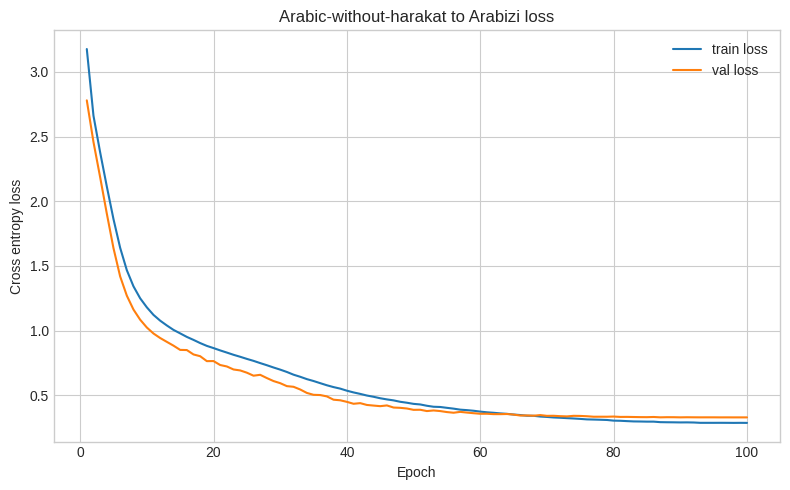

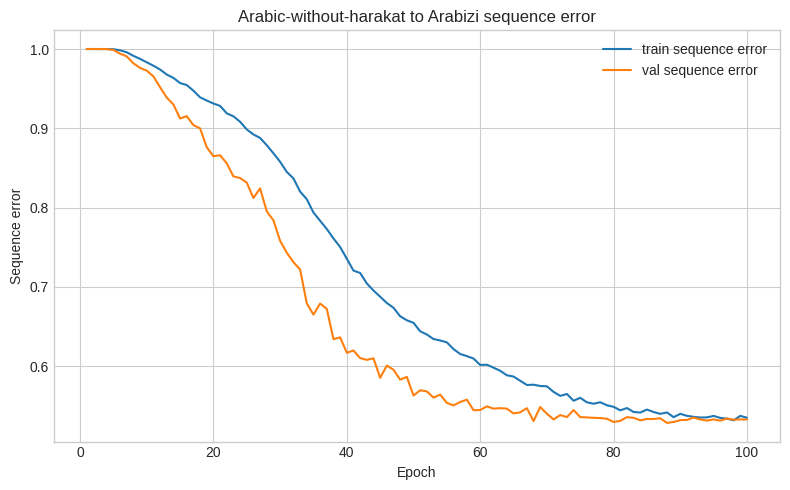

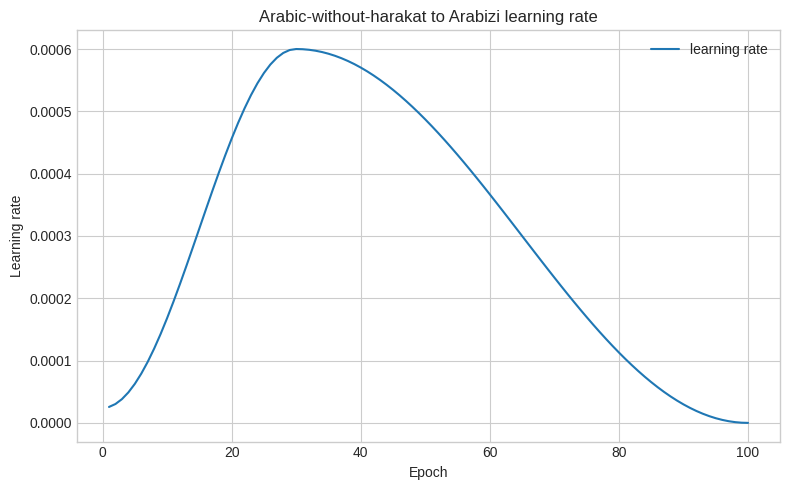

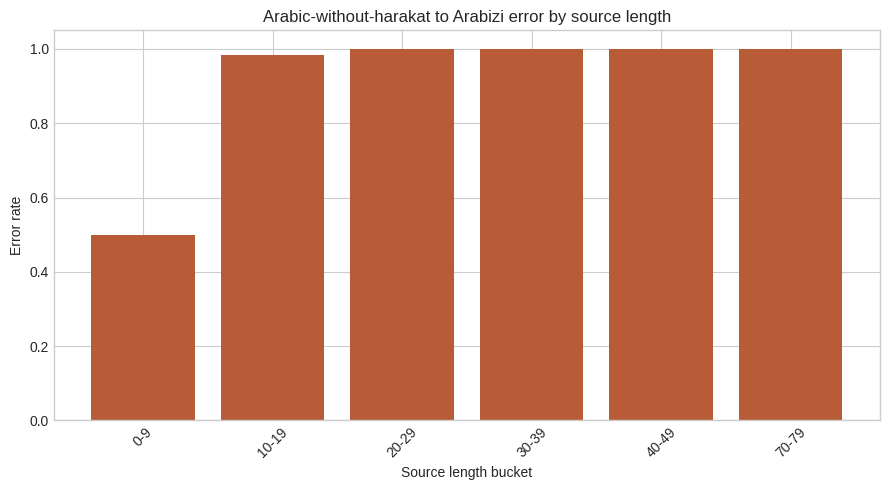

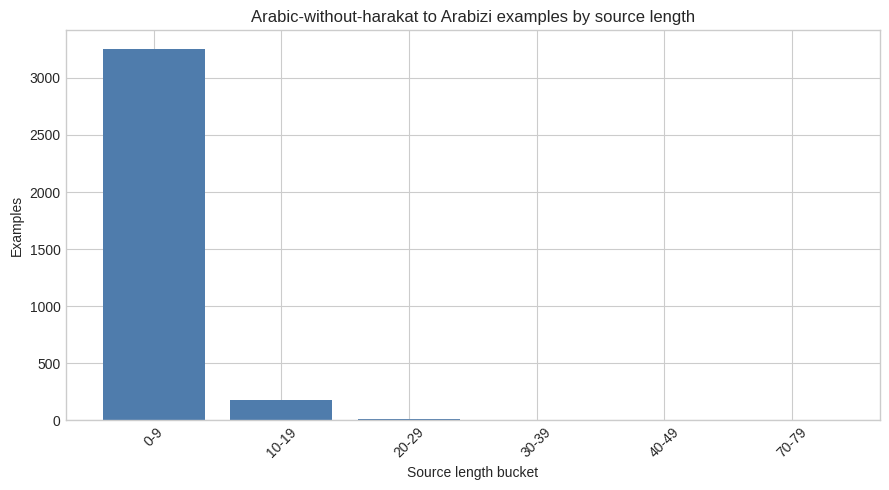

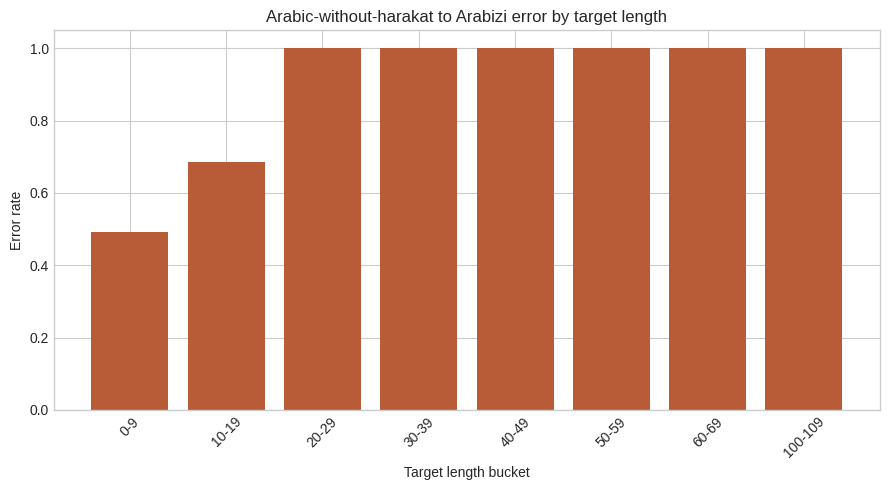

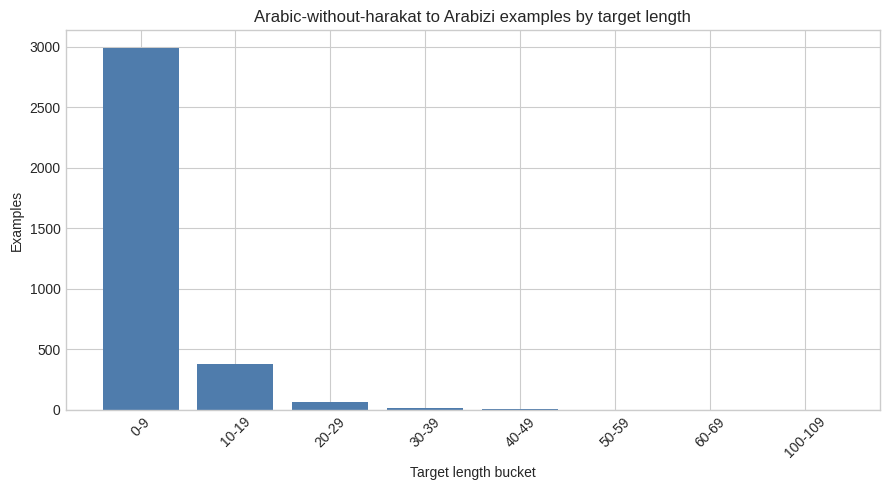

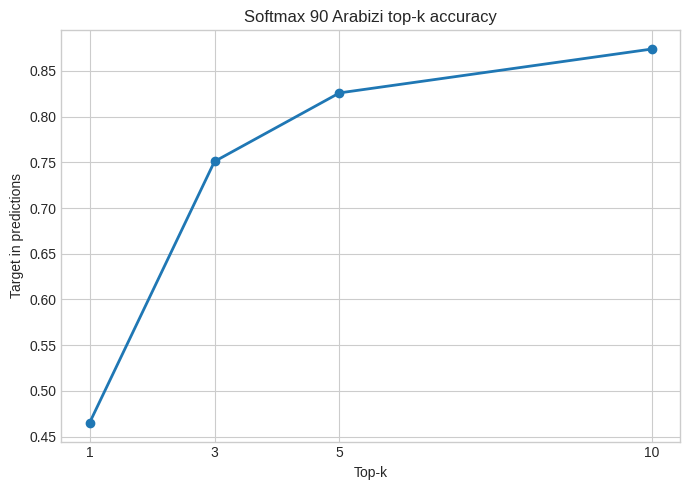

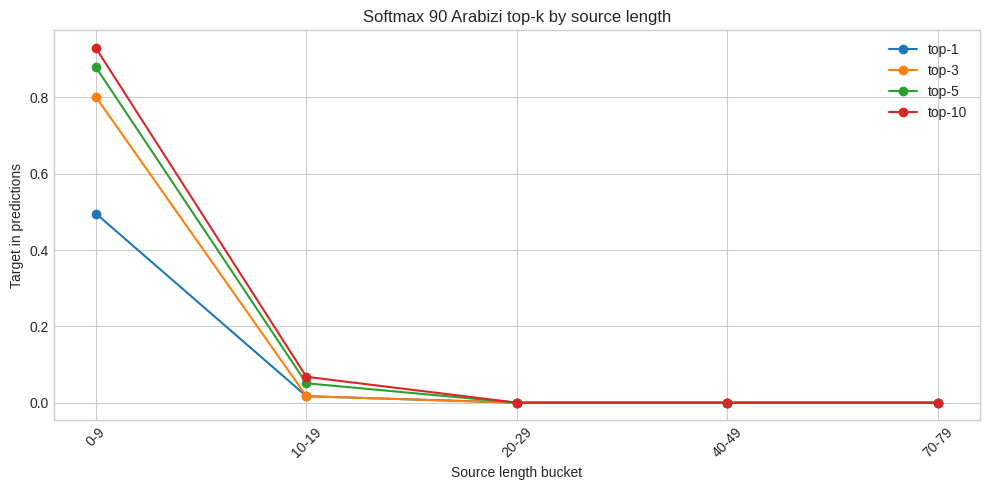

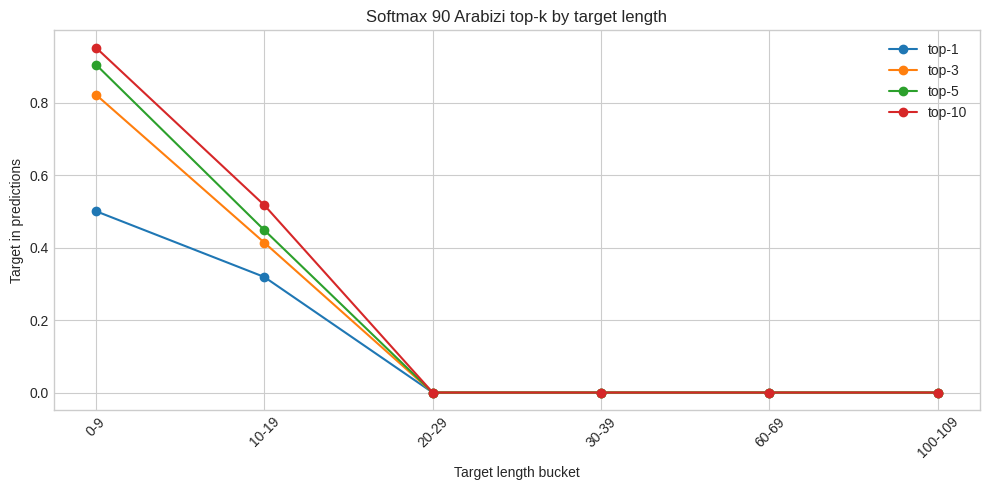

Saved plots to: /content/drive/MyDrive/arabizi/train_arabic_wo_harakat_to_arabizi_files


In [18]:
####################################
# paper-ready training and analysis plots
####################################
plot_training_figures(METRICS_FILE, RESULTS_DIR, show=True)
plot_error_analysis_figures(ERROR_ANALYSIS_FILE, RESULTS_DIR, show=True)
plot_top_k_figures(TOPK_METRICS_FILE, TOPK_BY_LENGTH_FILE, RESULTS_DIR, show=True)
print("Saved plots to:", RESULTS_DIR)